# Empirical Analysis of Assumption 3 Violation under KMZ Standardization

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hfallahgoul/HDL-JoE-replication/blob/main/01_Empirical_Analysis_Assumption_3_Violation.ipynb)

This notebook empirically evaluates the stability of the Random Fourier Feature (RFF) map under the data-dependent, within-window standardization of Kozak, Nagel, and Santosh (KMZ, 2024). It replicates the 12-panel figure (`same_input_different_output.pdf`) and summary statistics showing the violation of Assumption 3 across rolling windows.

In [ ]:
import os
import sys

CSV_NAME = 'PredictorData2021.csv'
GITHUB_RAW_URL = f'https://raw.githubusercontent.com/hfallahgoul/HDL-JoE-replication/main/{CSV_NAME}'
DRIVE_FALLBACK = f'/content/drive/MyDrive/HDL_Finance/{CSV_NAME}'

def get_data_path(csv_name=CSV_NAME):
    if os.path.exists(csv_name):
        return csv_name
    elif os.path.exists(DRIVE_FALLBACK):
        return DRIVE_FALLBACK
    else:
        try:
            import urllib.request
            print(f'Downloading {csv_name} from GitHub repository...')
            urllib.request.urlretrieve(GITHUB_RAW_URL, csv_name)
            if os.path.exists(csv_name):
                print(f'Download complete: {csv_name}')
                return csv_name
        except Exception as e:
            print(f'Note: Automatic download from GitHub failed ({e}).')
    return csv_name

csv_path = get_data_path()
print(f'Using dataset path: {csv_path}')


The file exists at: /content/drive/MyDrive/HDL_Finance/PredictorData2021.csv




# Comparing RFF for Standard and Standardised

--- Data Loading Successful ---
    Sample: 1929-01 to 2020-12
    Observations: 1104

--- Building fixed projection matrix (K=15, P=500, seed=42) ---

--- Test points defined: ['Mean', '90th percentile', '10th percentile'] ---

--- Rolling through windows (T=12) ---
    Total windows: 1093

Test point         Std raw (mean)       Std std (mean)       Ratio     
--------------------------------------------------------------------
Mean               0.000000             0.1878               16989501877188.0x
90th percentile    0.000000             0.1858               16169830448413.5x
10th percentile    0.000000             0.1837               16096649733183.3x
Interpretation: standard RFF std should be ~0 (fixed omega,
fixed x_test => fixed z(x_test)). Standardized RFF std reflects
the structural variation in D across windows — the core of
the Assumption 3 violation.


--- Figure saved to same_input_different_output.pdf ---


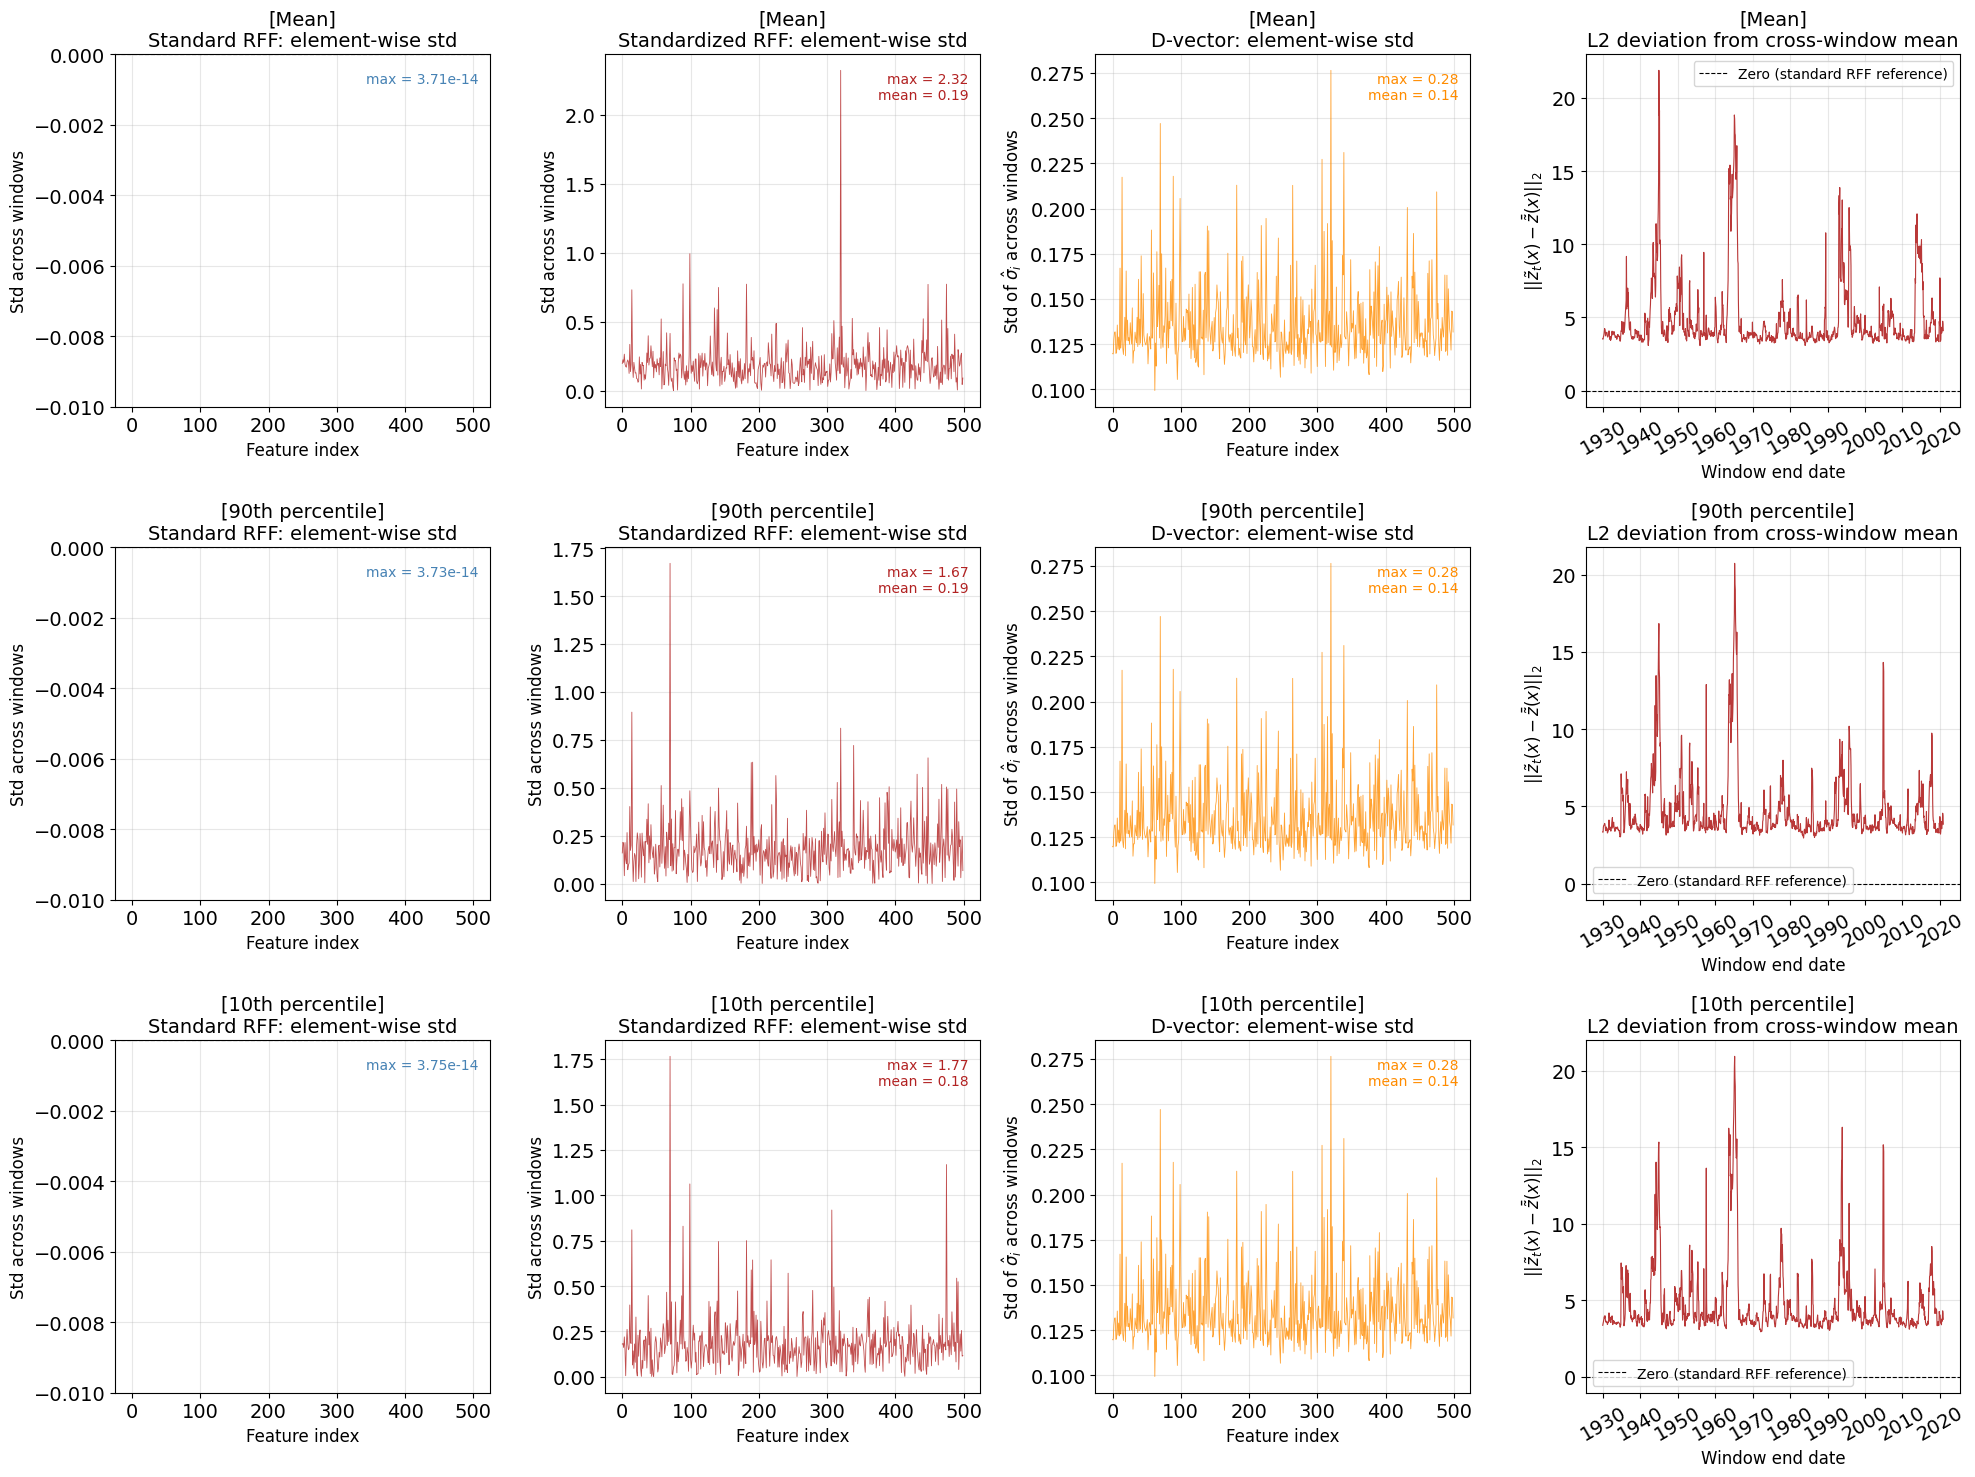

In [ ]:
"""
Same Input, Different Output: A Direct Test of Feature Map Stability
=====================================================================
Core argument
-------------
For standard RFF, z(x) depends only on x and the fixed projections omega.
Holding both constant, the same input x must produce the same feature
vector in every window — by construction.

For standardized RFF, z_tilde(x) = D^{-1} z(x) where D = diag(sigma_hat_i)
is estimated from the T observations in the current training window.
The same input x therefore produces a *different* feature vector in every
window, even when omega is held fixed.

This is precisely the content of the Assumption 3 violation: there is no
single stable population object Psi_tilde for the spectral distribution to
converge to, because the feature map itself changes with the training window.

Test design
-----------
1. Fix omega (constant seed) so RFF projections never change.
2. Choose one or more fixed test points x_test.
3. For every rolling window:
       a. Compute D from the T training observations in that window.
       b. Evaluate the standard and standardized feature vectors at x_test.
4. Measure and plot the element-wise variation of both feature vectors
   across windows.

For standard RFF the element-wise std across windows is identically zero.
For standardized RFF it is strictly positive and varies across features.

Usage
-----
    python same_input_different_output.py --data path/to/goyal_welch.csv
"""

import argparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

csv_path = get_data_path()


# =============================================================================
# 1. DATA LOADING
# =============================================================================

def load_and_prepare_goyal_welch_data(csv_path, start_date='1926-01-01',
                                       end_date='2020-12-31'):
    df = pd.read_csv(csv_path)
    df['Date'] = pd.to_datetime(df['yyyymm'], format='%Y%m')
    df = df.set_index('Date')

    cols_to_numeric = ['D12', 'E12', 'Index', 'BAA', 'AAA',
                       'lty', 'tbl', 'corpr', 'ltr', 'CRSP_SPvw', 'Rfree']
    for col in cols_to_numeric:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df['dp']        = np.log(df['D12'])  - np.log(df['Index'])
    df['dy']        = np.log(df['D12'])  - np.log(df['Index'].shift(1))
    df['ep']        = np.log(df['E12'])  - np.log(df['Index'])
    df['de']        = np.log(df['D12'])  - np.log(df['E12'])
    df['dfy']       = df['BAA']   - df['AAA']
    df['tms']       = df['lty']   - df['tbl']
    df['dfr']       = df['corpr'] - df['ltr']
    df['exret']     = df['CRSP_SPvw'] - df['Rfree']
    df['lag_exret'] = df['exret'].shift(1)

    predictor_mnemonics = [
        'dfy', 'infl', 'svar', 'de', 'lty', 'tms', 'tbl', 'dfr',
        'dp', 'dy', 'ltr', 'ep', 'b/m', 'ntis', 'lag_exret'
    ]
    df_filtered = df.loc[start_date:end_date, predictor_mnemonics].copy()
    df_cleaned  = df_filtered.ffill()

    min_obs = 36
    df_standardized = pd.DataFrame(index=df_cleaned.index,
                                   columns=df_cleaned.columns)
    for i in range(min_obs, len(df_cleaned)):
        expanding_window = df_cleaned.iloc[0:i]
        expanding_std    = expanding_window.std()
        expanding_std[expanding_std == 0] = 1
        df_standardized.iloc[i] = df_cleaned.iloc[i] / expanding_std

    final_df = df_standardized.dropna().astype(np.float64)
    print("--- Data Loading Successful ---")
    print(f"    Sample: {final_df.index.min().strftime('%Y-%m')} "
          f"to {final_df.index.max().strftime('%Y-%m')}")
    print(f"    Observations: {len(final_df)}")
    return final_df


# =============================================================================
# 2. RFF PROJECTION MATRIX  (fixed once, never redrawn)
# =============================================================================

def build_projection_matrix(K, P, gamma=2.0, seed=42):
    """
    Draws and returns the K x (P/2) projection matrix omega.
    Called once. All subsequent RFF evaluations reuse this matrix,
    ensuring that any variation in feature vectors is attributable
    solely to the training data, not to different projections.
    """
    if P % 2 != 0:
        raise ValueError("P must be even.")
    np.random.seed(seed)
    omega = np.random.normal(size=(K, P // 2))
    return omega


def evaluate_rff(x, omega, gamma=2.0):
    """
    Evaluates the standard (unstandardized) RFF map at a single
    K-dimensional input vector x.

    Returns a P-dimensional feature vector z(x).
    z_i(x) = sqrt(2) * sin(gamma * omega_i' x)  for i = 1 ... P/2
    z_i(x) = sqrt(2) * cos(gamma * omega_i' x)  for i = P/2+1 ... P
    """
    proj = gamma * (omega.T @ x)           # shape (P/2,)
    z    = np.sqrt(2) * np.concatenate([np.sin(proj), np.cos(proj)])
    return z                               # shape (P,)


def evaluate_standardized_rff(x, omega, Z_window, gamma=2.0):
    """
    Evaluates the standardized RFF map at x using the D vector estimated
    from the current training window Z_window (T x P).

    Steps:
        1. Evaluate standard z(x).
        2. Compute D = diag(sigma_hat_1,...,sigma_hat_P) from Z_window.
        3. Return z_tilde(x) = D^{-1} z(x).

    The key point: step 2 depends on Z_window, so z_tilde(x) is
    different for every window even when x and omega are fixed.
    """
    z     = evaluate_rff(x, omega, gamma)
    d     = Z_window.std(axis=0, ddof=1)   # shape (P,)
    d     = np.where(d < 1e-12, np.nan, d) # guard zero-variance features
    z_std = z / d
    return z_std, d


# =============================================================================
# 3. ROLLING WINDOW EVALUATION
# =============================================================================

def collect_feature_vectors(predictors, omega, test_points, T=12, gamma=2.0):
    """
    Rolls through all windows of size T. For each window and each test
    point, records:
        - z(x_test)        : standard RFF  (should be identical every window)
        - z_tilde(x_test)  : standardized RFF (will vary across windows)
        - d_vector         : the D-vector for this window

    Returns
    -------
    results : dict keyed by test-point label, each value a dict with:
        'dates'    : list of window-end timestamps
        'z_std'    : (n_windows, P) array for standardized RFF
        'z_raw'    : (n_windows, P) array for standard RFF
        'd_vecs'   : (n_windows, P) array of D-vectors
    """
    dates  = predictors.index
    n_obs  = len(dates)
    P      = omega.shape[1] * 2

    # Pre-compute the full RFF matrix once (standard, no standardization)
    K      = omega.shape[0]
    X      = predictors.values             # (n_obs, K)
    proj   = gamma * (X @ omega)           # (n_obs, P/2)
    Z_full = np.sqrt(2) * np.hstack(
        [np.sin(proj), np.cos(proj)]
    )                                       # (n_obs, P)

    results = {lbl: {'dates': [], 'z_std': [], 'z_raw': [], 'd_vecs': []}
               for lbl in test_points}

    for end_idx in range(T, n_obs + 1):
        start_idx  = end_idx - T
        window_end = dates[end_idx - 1]
        Z_window   = Z_full[start_idx:end_idx, :]   # (T, P)

        # D-vector for this window
        d = Z_window.std(axis=0, ddof=1)
        d = np.where(d < 1e-12, np.nan, d)

        for lbl, x_test in test_points.items():
            z_raw = evaluate_rff(x_test, omega, gamma)         # fixed
            z_std = z_raw / d                                   # window-specific

            results[lbl]['dates'].append(window_end)
            results[lbl]['z_raw'].append(z_raw)
            results[lbl]['z_std'].append(z_std)
            results[lbl]['d_vecs'].append(d)

    # Convert lists to arrays
    for lbl in results:
        for key in ('z_raw', 'z_std', 'd_vecs'):
            results[lbl][key] = np.array(results[lbl][key])  # (n_windows, P)

    return results


# =============================================================================
# 4. DEFINE TEST POINTS
# =============================================================================

def build_test_points(predictors):
    """
    Constructs three economically interpretable test points:
        'grand_mean'  : time-series mean of each predictor — a neutral,
                        average economic state.
        'high_stress' : 90th percentile of each predictor — a stressed
                        economic environment.
        'low_stress'  : 10th percentile of each predictor — a calm
                        economic environment.

    Using multiple test points confirms that the result is not specific
    to one particular location in predictor space.
    """
    X = predictors.values
    return {
        'Mean'  : X.mean(axis=0),
        '90th percentile' : np.percentile(X, 90, axis=0),
        '10th percentile'  : np.percentile(X, 10, axis=0),
    }


# =============================================================================
# 5. PLOTTING
# =============================================================================

def plot_results(results, P, output_path):
    """
    Four panels per test point (3 test points = 12 panels total, arranged
    in a 3 x 4 grid).

    For each test point:
        Panel A  Element-wise std of z(x_test) across windows — standard RFF.
                 Must be identically zero; shown as a check.
        Panel B  Element-wise std of z_tilde(x_test) across windows —
                 standardized RFF. Non-zero variation is the key finding.
        Panel C  Element-wise std of the D-vector across windows.
                 Shows that the variation in z_tilde is driven by D.
        Panel D  Time series of L2-distance ||z_tilde_t(x) - z_tilde_bar(x)||
                 where z_tilde_bar is the cross-window mean feature vector.
                 Tracks how far the standardized representation of x_test
                 deviates from its average, window by window.
    """
    test_labels = list(results.keys())
    n_tests     = len(test_labels)

    # Increase overall font size for LaTeX compatibility
    plt.rcParams.update({'font.size': 14}) # Base font size

    fig, axes = plt.subplots(n_tests, 4, figsize=(20, 5 * n_tests))
    if n_tests == 1:
        axes = axes[np.newaxis, :]

    feature_idx = np.arange(P)

    for row, lbl in enumerate(test_labels):
        r        = results[lbl]
        z_raw    = r['z_raw']    # (n_windows, P)
        z_std    = r['z_std']    # (n_windows, P)
        d_vecs   = r['d_vecs']   # (n_windows, P)
        dates    = r['dates']

        # --- Panel A: element-wise std of standard RFF --------------------
        std_raw = np.nanstd(z_raw, axis=0)    # shape (P,) — should be ~0
        ax = axes[row, 0]
        ax.plot(feature_idx, std_raw, color='steelblue',
                linewidth=0.6, alpha=0.8)
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xlabel('Feature index', fontsize=12)
        ax.set_ylabel(r'Std across windows', fontsize=12)
        ax.set_title(f'[{lbl}]\nStandard RFF: element-wise std', fontsize=14)
        ax.set_ylim(bottom=-0.01)
        ax.grid(True, alpha=0.3)
        # Annotate max
        ax.text(0.97, 0.95,
                f'max = {std_raw.max():.2e}',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=10, color='steelblue')

        # --- Panel B: element-wise std of standardized RFF ----------------
        std_std = np.nanstd(z_std, axis=0)    # shape (P,) — key finding
        ax = axes[row, 1]
        ax.plot(feature_idx, std_std, color='firebrick',
                linewidth=0.6, alpha=0.8)
        ax.set_xlabel('Feature index', fontsize=12)
        ax.set_ylabel(r'Std across windows', fontsize=12)
        ax.set_title(f'[{lbl}]\nStandardized RFF: element-wise std', fontsize=14)
        ax.grid(True, alpha=0.3)
        ax.text(0.97, 0.95,
                f'max = {std_std.max():.2f}\nmean = {np.nanmean(std_std):.2f}',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=10, color='firebrick')

        # --- Panel C: element-wise std of D-vector ------------------------
        std_d = np.nanstd(d_vecs, axis=0)
        ax = axes[row, 2]
        ax.plot(feature_idx, std_d, color='darkorange',
                linewidth=0.6, alpha=0.8)
        ax.set_xlabel('Feature index', fontsize=12)
        ax.set_ylabel(r'Std of $\hat{\sigma}_i$ across windows', fontsize=12)
        ax.set_title(f'[{lbl}]\nD-vector: element-wise std', fontsize=14)
        ax.grid(True, alpha=0.3)
        ax.text(0.97, 0.95,
                f'max = {std_d.max():.2f}\nmean = {np.nanmean(std_d):.2f}',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=10, color='darkorange')

        # --- Panel D: L2-distance of z_tilde from its cross-window mean ---
        z_std_mean  = np.nanmean(z_std, axis=0, keepdims=True)  # (1, P)
        l2_dist     = np.sqrt(np.nansum((z_std - z_std_mean)**2, axis=1))
        ax = axes[row, 3]
        ax.plot(dates, l2_dist, color='firebrick',
                linewidth=0.8, alpha=0.9)
        ax.set_xlabel('Window end date', fontsize=12)
        ax.set_ylabel(r'$||\tilde{z}_t(x) - \bar{\tilde{z}}(x)||_2$',
                      fontsize=12)
        ax.set_title(f'[{lbl}]\nL2 deviation from cross-window mean',
                     fontsize=14)
        ax.grid(True, alpha=0.3)
        # Reference line: expected L2 distance if z_tilde were constant
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--',
                   label='Zero (standard RFF reference)')
        ax.legend(fontsize=10)

        # Rotate x-axis labels for readability
        ax.tick_params(axis='x', rotation=30)

    # Remove fig.suptitle entirely
    # fig.suptitle(
    #     r'Same Input, Different Output: $z(x_{\rm test})$ vs '
    #     r'$\tilde{z}(x_{\rm test})$ across rolling windows'
    #     f'\n$P = {P}$, $T$ fixed, $\omega$ fixed (seed=42)',
    #     fontsize=13, y=1.01
    # )
    plt.tight_layout()
    fig.savefig(output_path, bbox_inches='tight', dpi=150)
    print(f"\n--- Figure saved to {output_path} ---")
    plt.show()


# =============================================================================
# 6. SUMMARY STATISTICS
# =============================================================================

def print_summary(results):
    """
    Prints a concise table comparing the cross-window variation in
    z(x_test) versus z_tilde(x_test) for each test point.

    The ratio (mean std of standardized) / (mean std of standard) is the
    simplest scalar summary: under the null of a stable population it should
    be close to 1; in practice it is much larger.
    """
    print("\n" + "=" * 68)
    print(f"{'Test point':<18} {'Std raw (mean)':<20} "
          f"{'Std std (mean)':<20} {'Ratio':<10}")
    print("-" * 68)
    for lbl, r in results.items():
        mean_std_raw = np.nanstd(r['z_raw'], axis=0).mean()
        mean_std_std = np.nanstd(r['z_std'], axis=0).mean()
        ratio        = mean_std_std / (mean_std_raw + 1e-16)
        print(f"{lbl:<18} {mean_std_raw:<20.6f} {mean_std_std:<20.4f} "
              f"{ratio:<10.1f}x")
    print("=" * 68)
    print("Interpretation: standard RFF std should be ~0 (fixed omega,")
    print("fixed x_test => fixed z(x_test)). Standardized RFF std reflects")
    print("the structural variation in D across windows — the core of")
    print("the Assumption 3 violation.\n")


# =============================================================================
# 7. MAIN
# =============================================================================

def run_analysis(csv_path, T=12, P=500, gamma=2.0, seed=42,
                 output_path='same_input_different_output.pdf'):

    # --- Load data -----------------------------------------------------------
    predictors = load_and_prepare_goyal_welch_data(csv_path)
    K          = predictors.shape[1]

    # --- Build fixed projection matrix (drawn once, never redrawn) ----------
    print(f"\n--- Building fixed projection matrix "
          f"(K={K}, P={P}, seed={seed}) ---")
    omega = build_projection_matrix(K, P, gamma=gamma, seed=seed)

    # --- Define test points --------------------------------------------------
    test_points = build_test_points(predictors)
    print(f"\n--- Test points defined: {list(test_points.keys())} ---")

    # --- Roll through windows and collect feature vectors -------------------
    print(f"\n--- Rolling through windows (T={T}) ---")
    results = collect_feature_vectors(
        predictors, omega, test_points, T=T, gamma=gamma
    )
    n_windows = len(results[list(results.keys())[0]]['dates'])
    print(f"    Total windows: {n_windows}")

    # --- Summary table -------------------------------------------------------
    print_summary(results)

    # --- Plots ---------------------------------------------------------------
    plot_results(results, P=P, output_path=output_path)


# =============================================================================
# 8. ENTRY POINT
# =============================================================================

# Directly call run_analysis with the predefined csv_path
run_analysis(
    csv_path    = csv_path,
    T           = 12,
    P           = 500,
    gamma       = 2.0,
    seed        = 42,
    output_path = 'same_input_different_output.pdf',
)
